# MCMC Convergence Diagnostics — Synthetic Data

Demonstrates convergence of the LG generation algorithm using controlled
synthetic experiments.  We first run a long "reference" MCMC chain to
establish the equilibrium, then launch **multiple independent chains**
from very different random initial densities and show they all converge
to the same equilibrium (spectral distance, edge count, degree-distribution
KS statistic all collapse).

**Design choice:** We use `d=0` (S_i = deg(i)) so the feedback is linear
and sigma=-6 produces a genuinely sparse equilibrium.  With `d>=1` the
neighbourhood sums grow quadratically with degree, requiring much more
negative sigma to stay sparse.

In [6]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.append('../..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import ks_2samp
from scipy.special import expit
from collections import deque

import src.logit_graph.graph as graph

plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams.update({
    'font.family': 'serif',
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'axes.linewidth': 1.0,
    'lines.linewidth': 1.8,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
def run_chain(n, d, sigma, max_iter, check_interval, er_p, ref_spectrum, ref_degrees):
    """Run one MCMC chain and record diagnostics at every check_interval."""
    gm = graph.GraphModel(n=n, d=d, sigma=sigma, er_p=er_p)

    spec_dists = []
    edge_counts = []
    ks_stats = []

    for i in range(max_iter):
        gm.add_remove_edge()

        if i % check_interval == 0:
            cur_spec = graph.GraphModel.calculate_spectrum(gm.graph)
            spec_dists.append(float(np.linalg.norm(cur_spec - ref_spectrum)))
            edge_counts.append(gm._edge_count)
            cur_deg = gm.graph.sum(axis=1)
            ks_stat, _ = ks_2samp(cur_deg, ref_degrees)
            ks_stats.append(ks_stat)

    return spec_dists, edge_counts, ks_stats

In [8]:
# --- Experiment parameters ---
# d=0 keeps feedback linear (S_i = deg(i)), so sigma=-6 yields a sparse graph.
# With d>=1 the neighbourhood sums grow quadratically with degree,
# requiring much more negative sigma to avoid saturating to a complete graph.
N = 500
D = 0
SIGMA = -6.0
N_CHAINS = 5
MAX_ITER = 500_000        # per chain (fast with d=0)
CHECK_INTERVAL = 500

# Generate a well-equilibrated reference graph by running a long chain.
# Use the same fixed-iteration approach as the test chains so both
# sample from the true stationary distribution.
print('Generating reference (long-run equilibrium) graph ...')
gt_model = graph.GraphModel(n=N, d=D, sigma=SIGMA, er_p=0.05)
for _ in range(MAX_ITER):
    gt_model.add_remove_edge()
gt_spectrum = graph.GraphModel.calculate_spectrum(gt_model.graph)
gt_degrees = gt_model.graph.sum(axis=1)
gt_edges = gt_model._edge_count
gt_density = gt_edges / (N * (N - 1) / 2)
print(f'Reference: {gt_edges} edges, mean degree {gt_degrees.mean():.2f}, '
      f'density {gt_density:.4f}')

Generating reference (long-run equilibrium) graph ...
Reference: 122637 edges, mean degree 490.55, density 0.9831


In [9]:
# Run N_CHAINS independent chains from different random ER seeds
results = []
er_ps = [0.001, 0.01, 0.05, 0.10, 0.20]  # varied initial densities

for chain_id in range(N_CHAINS):
    p0 = er_ps[chain_id]
    print(f'Chain {chain_id+1}/{N_CHAINS} (ER p₀={p0}) ...')
    sd, ec, ks = run_chain(
        N, D, SIGMA, MAX_ITER, CHECK_INTERVAL, er_p=p0,
        ref_spectrum=gt_spectrum, ref_degrees=gt_degrees,
    )
    results.append({'p0': p0, 'spec_dist': sd, 'edges': ec, 'ks': ks})
    print(f'  final: spec_dist={sd[-1]:.2f}, edges={ec[-1]}, '
          f'density={ec[-1]/(N*(N-1)/2):.4f}, KS={ks[-1]:.4f}')

print(f'\nReference density was {gt_density:.4f} ({gt_edges} edges). Done.')

Chain 1/5 (ER p₀=0.001) ...
  final: spec_dist=22.57, edges=122392, density=0.9811, KS=0.1320
Chain 2/5 (ER p₀=0.01) ...
  final: spec_dist=12.54, edges=122503, density=0.9820, KS=0.0960
Chain 3/5 (ER p₀=0.05) ...
  final: spec_dist=5.58, edges=122590, density=0.9827, KS=0.0440
Chain 4/5 (ER p₀=0.1) ...
  final: spec_dist=7.09, edges=122682, density=0.9834, KS=0.0620
Chain 5/5 (ER p₀=0.2) ...
  final: spec_dist=33.47, edges=122995, density=0.9859, KS=0.2100

Reference density was 0.9831 (122637 edges). Done.


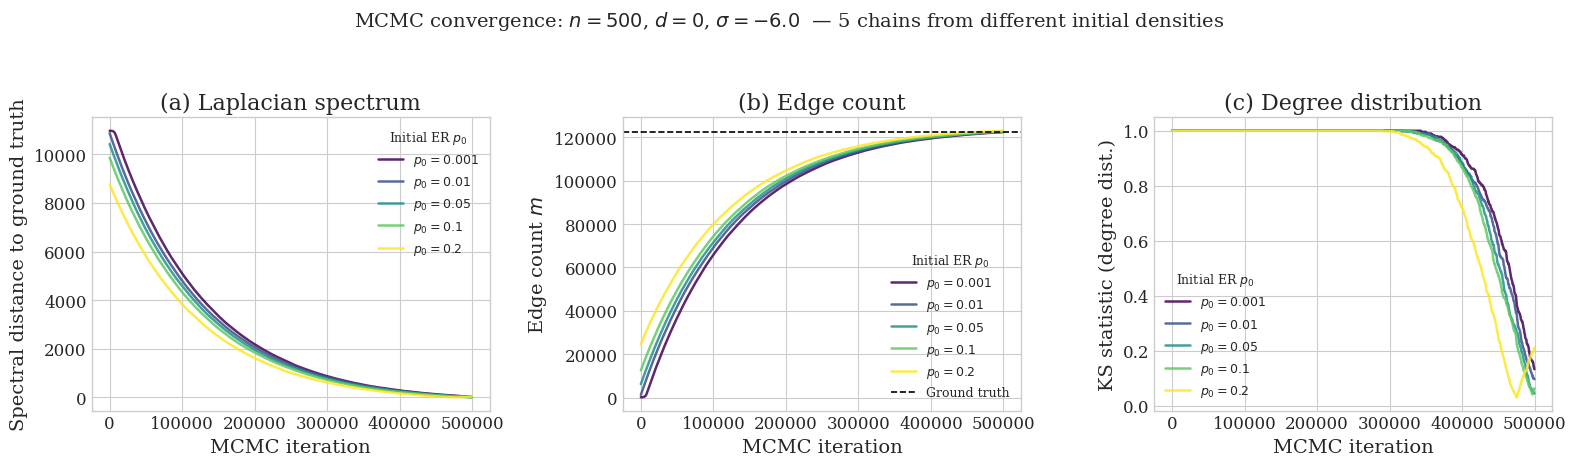

Saved to images/correction_paper/convergence_diagnostics.{png,pdf}


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
cmap = plt.cm.viridis
colors = [cmap(i / (N_CHAINS - 1)) for i in range(N_CHAINS)]

n_checks = len(results[0]['spec_dist'])
x_iters = np.arange(n_checks) * CHECK_INTERVAL

# (a) Spectral distance
ax = axes[0]
for i, r in enumerate(results):
    ax.plot(x_iters, r['spec_dist'], color=colors[i],
            label=f'$p_0={r["p0"]}$', alpha=0.85)
ax.set_xlabel('MCMC iteration')
ax.set_ylabel('Spectral distance to ground truth')
ax.set_title('(a) Laplacian spectrum')
ax.legend(fontsize=9, title='Initial ER $p_0$', title_fontsize=9)

# (b) Edge count
ax = axes[1]
for i, r in enumerate(results):
    ax.plot(x_iters, r['edges'], color=colors[i],
            label=f'$p_0={r["p0"]}$', alpha=0.85)
ax.axhline(gt_edges, color='k', ls='--', lw=1.2, label='Ground truth')
ax.set_xlabel('MCMC iteration')
ax.set_ylabel('Edge count $m$')
ax.set_title('(b) Edge count')
ax.legend(fontsize=9, title='Initial ER $p_0$', title_fontsize=9)

# (c) KS statistic
ax = axes[2]
for i, r in enumerate(results):
    ax.plot(x_iters, r['ks'], color=colors[i],
            label=f'$p_0={r["p0"]}$', alpha=0.85)
ax.set_xlabel('MCMC iteration')
ax.set_ylabel('KS statistic (degree dist.)')
ax.set_title('(c) Degree distribution')
ax.legend(fontsize=9, title='Initial ER $p_0$', title_fontsize=9)

fig.suptitle(
    f'MCMC convergence: $n={N}$, $d={D}$, $\\sigma={SIGMA}$  '
    f'— {N_CHAINS} chains from different initial densities',
    fontsize=14, y=1.04)
fig.tight_layout()

out_dir = '../../images/correction_paper'
os.makedirs(out_dir, exist_ok=True)
plt.savefig(f'{out_dir}/convergence_diagnostics.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{out_dir}/convergence_diagnostics.pdf', bbox_inches='tight')
plt.show()
print('Saved to images/correction_paper/convergence_diagnostics.{png,pdf}')